In [2]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [3]:
aln = ALNModel()
N = aln.params.N
aln.params.dt = .1

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [4]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

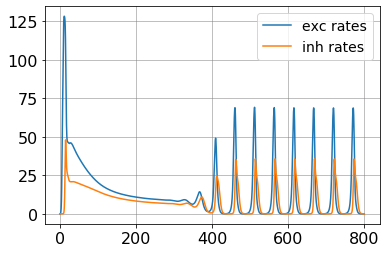

In [5]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

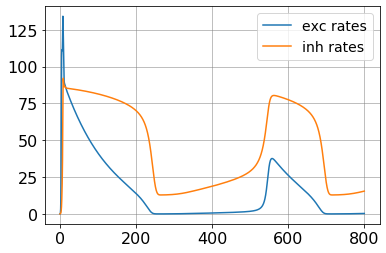

In [6]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

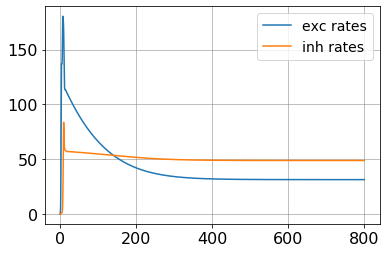

[31.3076 48.768 ]


In [7]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

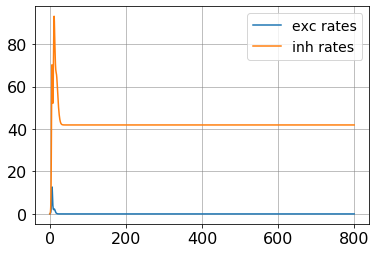

[4.4580e-10 4.1918e+01]


In [8]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [18]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000
set_params_slow()
initVars = slow_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
                    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 ]

sheet = "C_b_"

target_rates = np.array( [down_rates[0], down_rates[1]])

In [19]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

In [20]:
# B.0.a)

dur = 700
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

## 0

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  50.7604443566146
RUN  2 , total integrated cost =  47.062761090267585
RUN  3 , total integrated cost =  38.19018247323456
RUN  4 , total integrated cost =  30.764114036833877
RUN  5 , total integrated cost =  26.62456482154474
RUN  6 , total integrated cost =  4.136614252122513
RUN  7 , total integrated cost =  1.7463502960303567
RUN  8 , total integrated cost =  0.1407900086853639
RUN  9 , total integrated cost =  0.01431750996175983
RUN  10 , total integrated cost =  0.0005001746942573625
RUN  11 , total integrated cost =  3.3980384531980083e-06
RUN  12 , total integrated cost =  3.635014593989161e-07
RUN  13 , total integrated cost =  1.7388477733234924e-08
RUN  14 , total integrated cost =  3.2083079610525043e-09
RUN  15 , total integrated cost =  2.4162643726378993e-17
RUN  16 , total integrated c

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 max iteration reached, step size =  1.6401064715739963e-141
RUN  17 , total integrated cost =  2.4153762584048975e-17
Control only changes marginally.
RUN  17 , total integrated cost =  2.4153762584048975e-17
Improved over  17  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -81.18634218060225 -81.02111046165749


C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2352: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2200: RuntimeWarning: invalid value encountered in double_scalars
  return abs(x - np.round(x)) < 1e-10
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:1123: RuntimeWarning: invalid value encountered in double_scalars
  coeff = np.round(x / b ** exponent)
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2352: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2200: RuntimeWarning: invalid value encountered in double_scalars
  return abs(x - np.round(x)) < 1e-10
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:1123: RuntimeWarning: invalid value encountered in double_scalars
  coeff = np.round(x / b ** exponent)


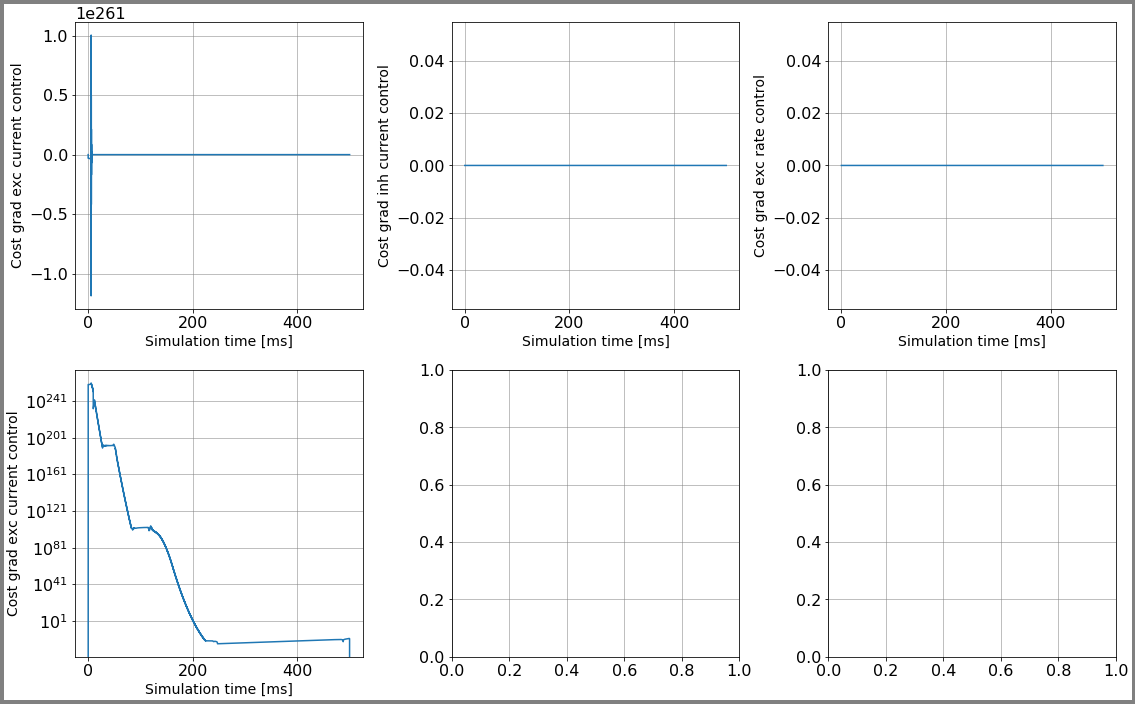

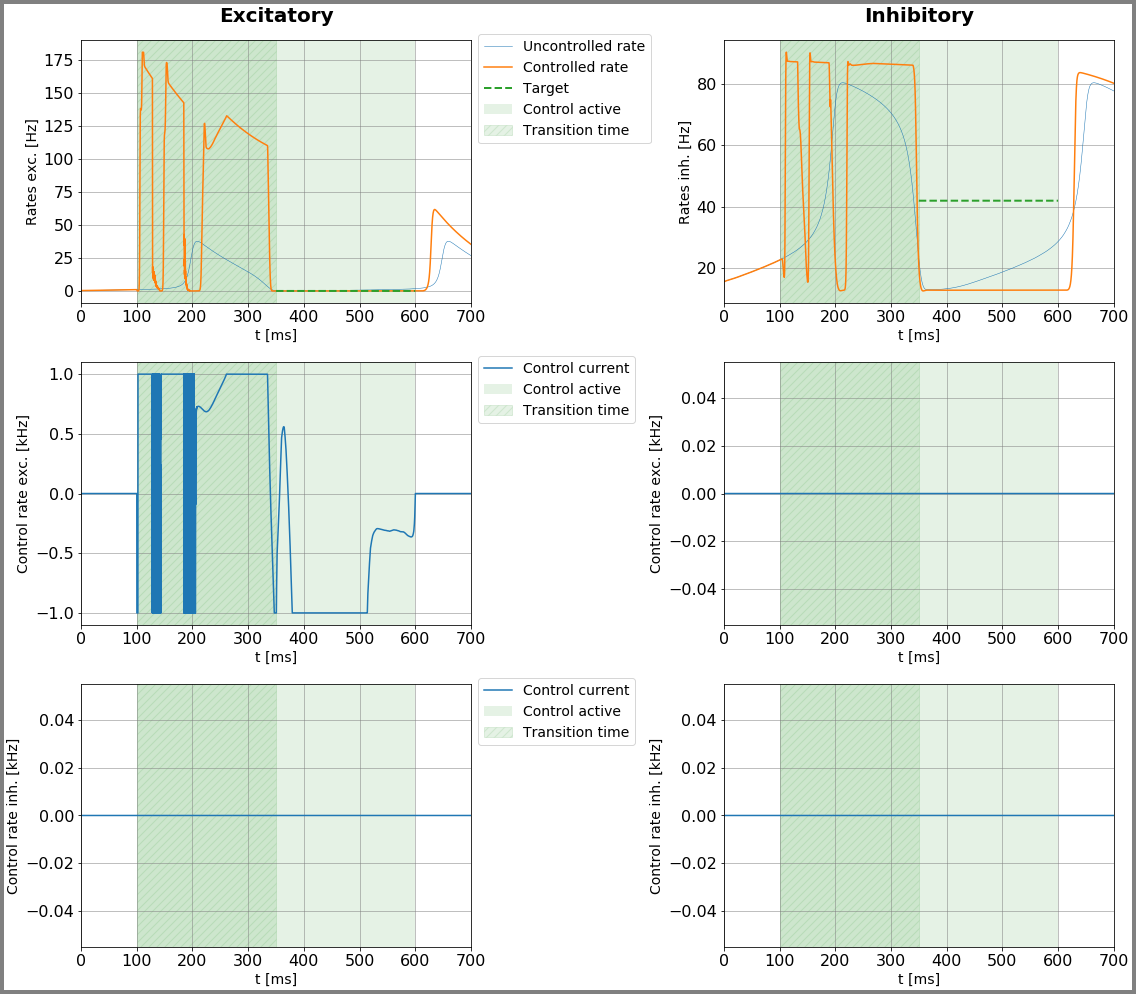

In [25]:
case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.793336333878
RUN  2 , total integrated cost =  50.45638423201447
RUN  3 , total integrated cost =  48.92983543886496
RUN  4 , total integrated cost =  48.17413088367054
RUN  5 , total integrated cost =  47.37247279255281
RUN  6 , total integrated cost =  46.725750628413515
RUN  7 , total integrated cost =  45.995208149118184
RUN  8 , total integrated cost =  45.291004204839204
RUN  9 , total integrated cost =  44.5030756821373
RUN  10 , total integrated cost =  44.055938929104826
RUN  11 , total integrated cost =  43.5133020668537
RUN  12 , total integrated cost =  43.08864086509519
RUN  13 , total integrated cost =  42.58674176002722
RUN  14 , total integrated cost =  41.97076218934606
RUN  15 , total integrated cost =  41.30045876572673
RUN  16 , total integrated cost =  40.565627544641046
RUN  17 , total integrated cost =  39.97428597024719


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  175 , total integrated cost =  38.03448023611291
Improved over  175  iterations by  40.412557201913415  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -60.74210188764923 -60.735837330190165


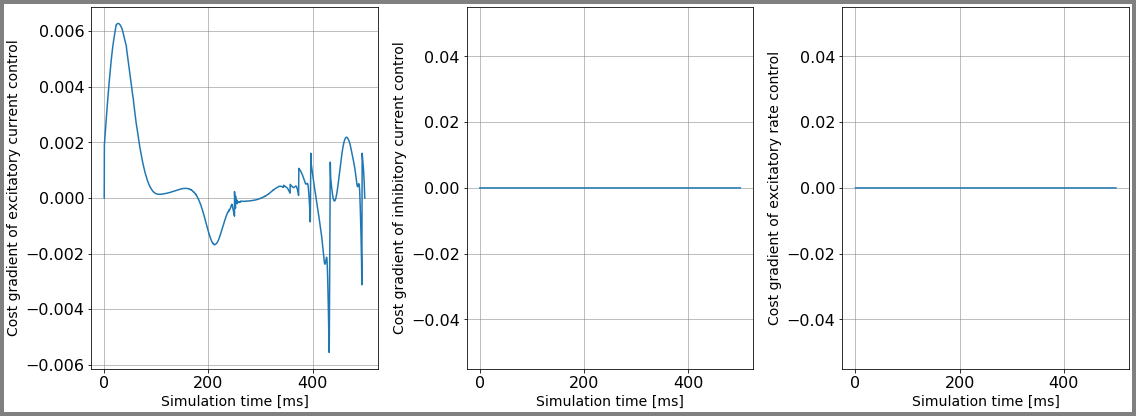

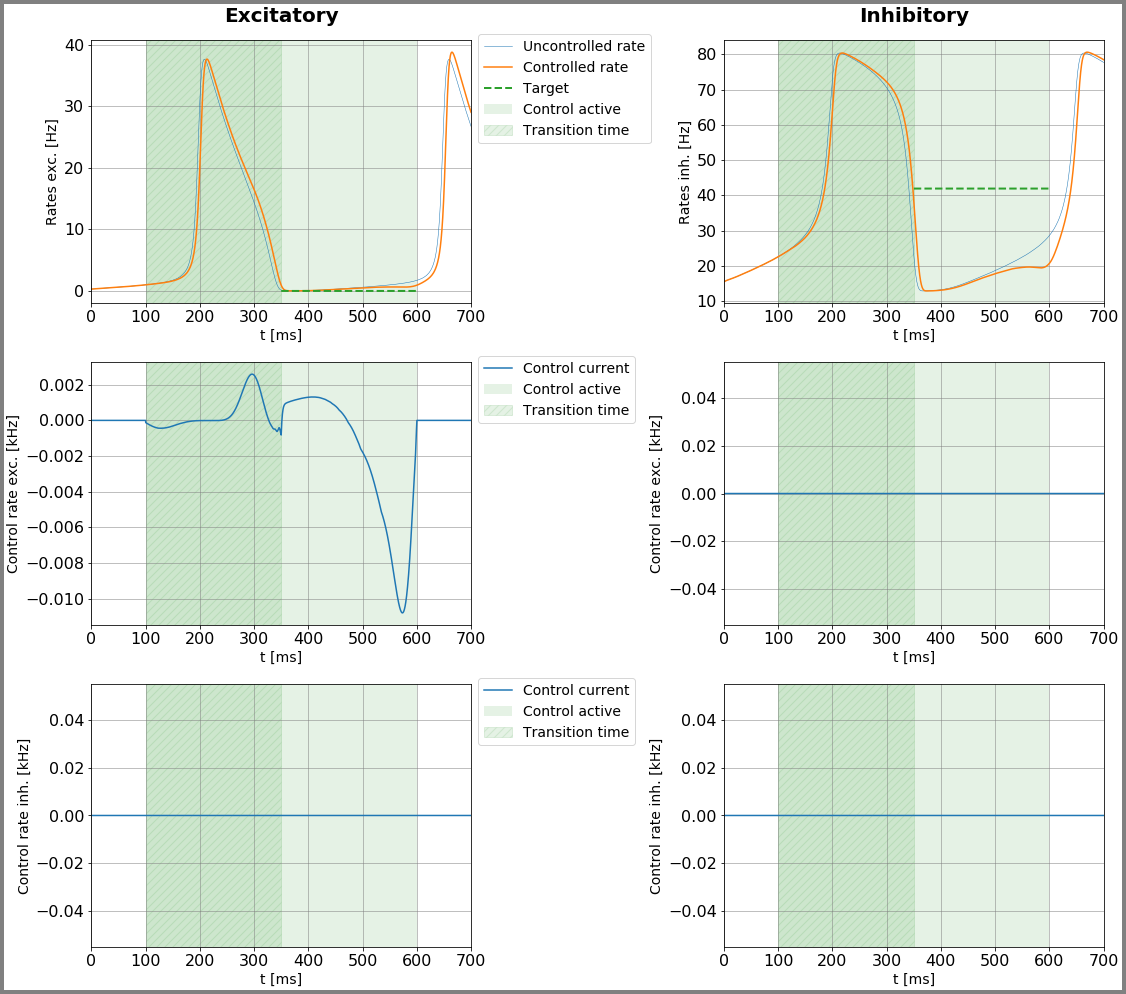

In [12]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 0
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 2

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42194.29441539813
RUN  1 , total integrated cost =  39774.38492251048
RUN  2 , total integrated cost =  19035.67926255259
RUN  3 , total integrated cost =  18462.38044698497
RUN  4 , total integrated cost =  17997.504879096425
RUN  5 , total integrated cost =  17475.87038174764
RUN  6 , total integrated cost =  14380.651459399627
RUN  7 , total integrated cost =  13261.296176933298
RUN  8 , total integrated cost =  8678.482808906585
RUN  9 , total integrated cost =  8533.797760070896
RUN  10 , total integrated cost =  8191.823097815022
RUN  11 , total integrated cost =  8033.4539477145045
RUN  12 , total integrated cost =  7752.0230384155575
RUN  13 , total integrated cost =  7655.083672826352
RUN  14 , total integrated cost =  7078.706258876811
RUN  15 , total integrated cost =  6824.118321286941
RUN  16 , total integrated cost =  5526.0969243358
RUN  1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  2192 , total integrated cost =  63.162403565034445
Improved over  2192  iterations by  99.85030581873652  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5295727170742817
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.55836937325112
Problem in initial value trasfer:  tau_exc 14.884010616351775 15.367537743292699
Problem in initial value trasfer:  Vmean_exc -60.24075882384744 -60.09904282032982


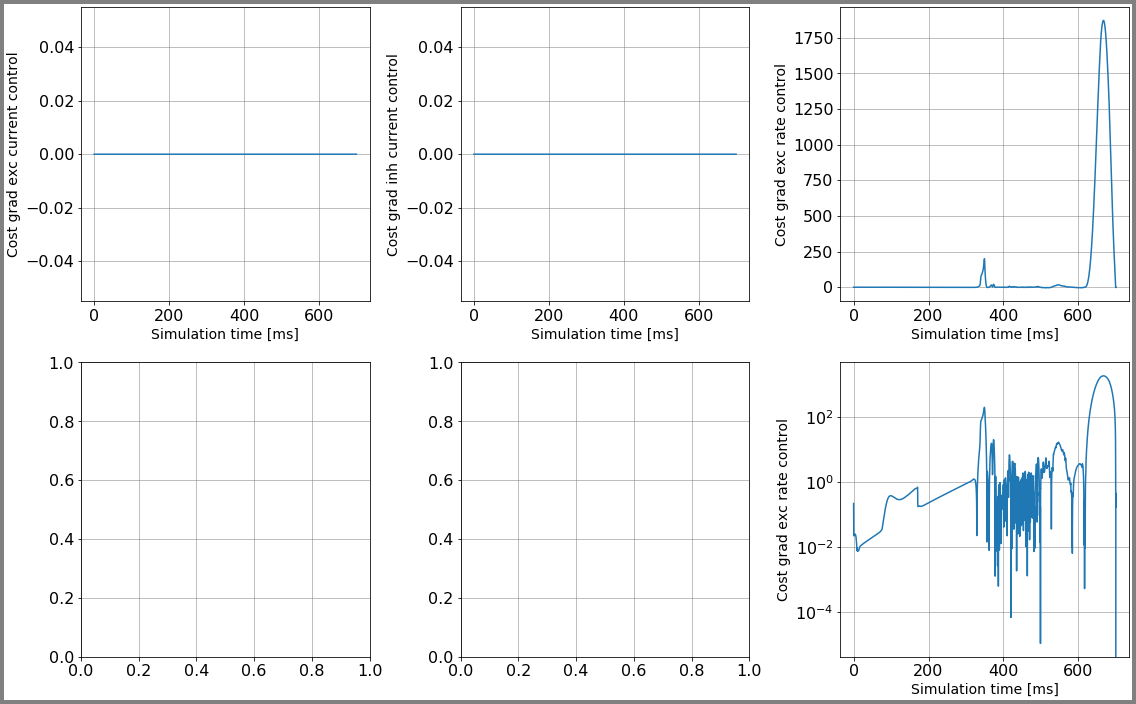

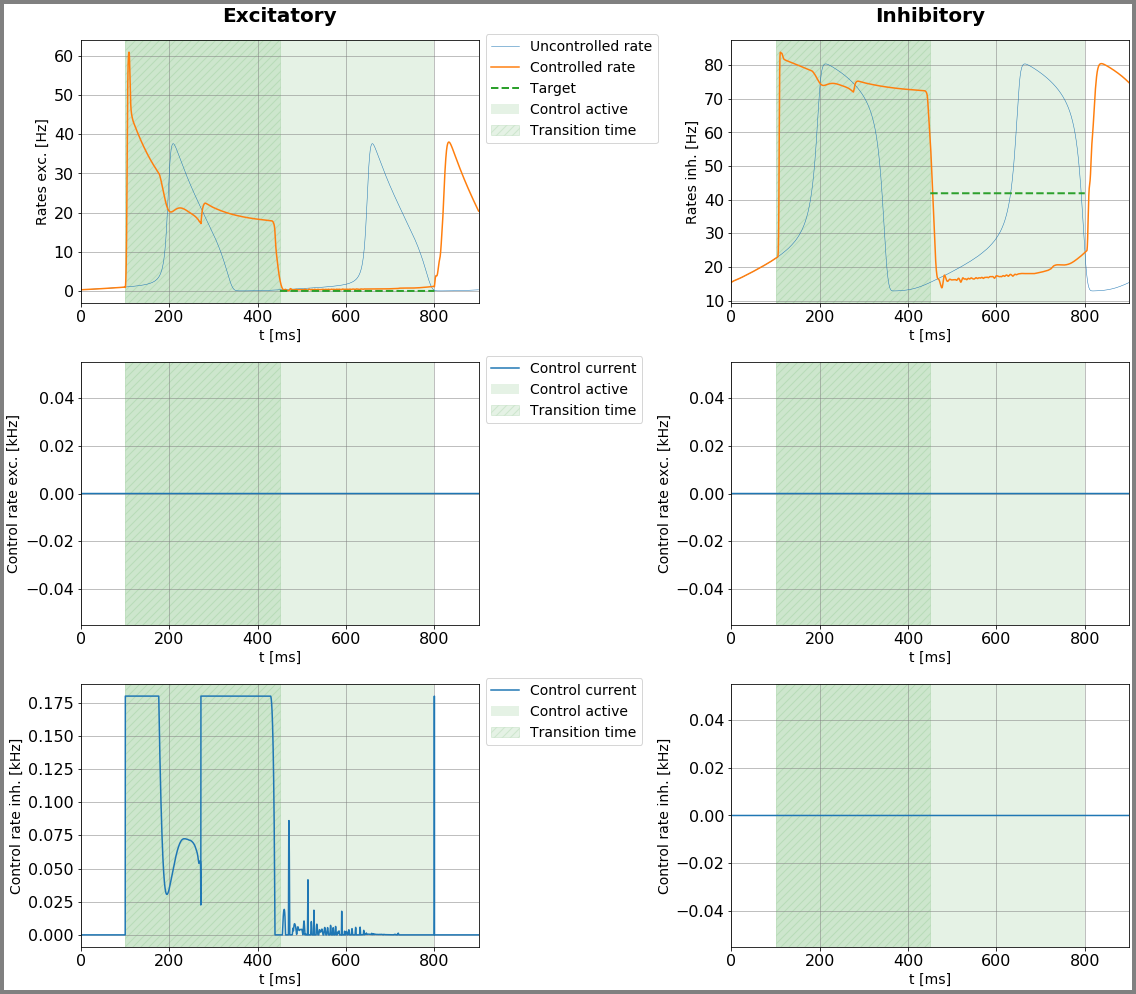

In [28]:
case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42194.29441539813
RUN  1 , total integrated cost =  40444.3771494211
RUN  2 , total integrated cost =  19556.422724733202
RUN  3 , total integrated cost =  18910.46518024668
RUN  4 , total integrated cost =  18477.018399496814
RUN  5 , total integrated cost =  17885.477164721793
RUN  6 , total integrated cost =  9821.61791800775
RUN  7 , total integrated cost =  9614.90620281174
RUN  8 , total integrated cost =  8847.57459064811
RUN  9 , total integrated cost =  8682.926177156043
RUN  10 , total integrated cost =  8099.375584347203
RUN  11 , total integrated cost =  7949.044826595098
RUN  12 , total integrated cost =  7690.338475126976
RUN  13 , total integrated cost =  7521.756011864381
RUN  14 , total integrated cost =  7321.559704295981
RUN  15 , total integrated cost =  7187.951534529787
RUN  16 , total integrated cost =  6835.41479043022
RUN  17 , total integrated cost =  6177.55068193346
RUN  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  181.90353505989583
RUN  5000 , total integrated cost =  181.90353505989583
Improved over  5000  iterations by  99.56889068159529  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5385174154922163
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.57102719819022
Problem in initial value trasfer:  tau_exc 14.884010616351775 15.251155757673324
Problem in initial value trasfer:  Vmean_exc -60.102013519577994 -60.22849416690967


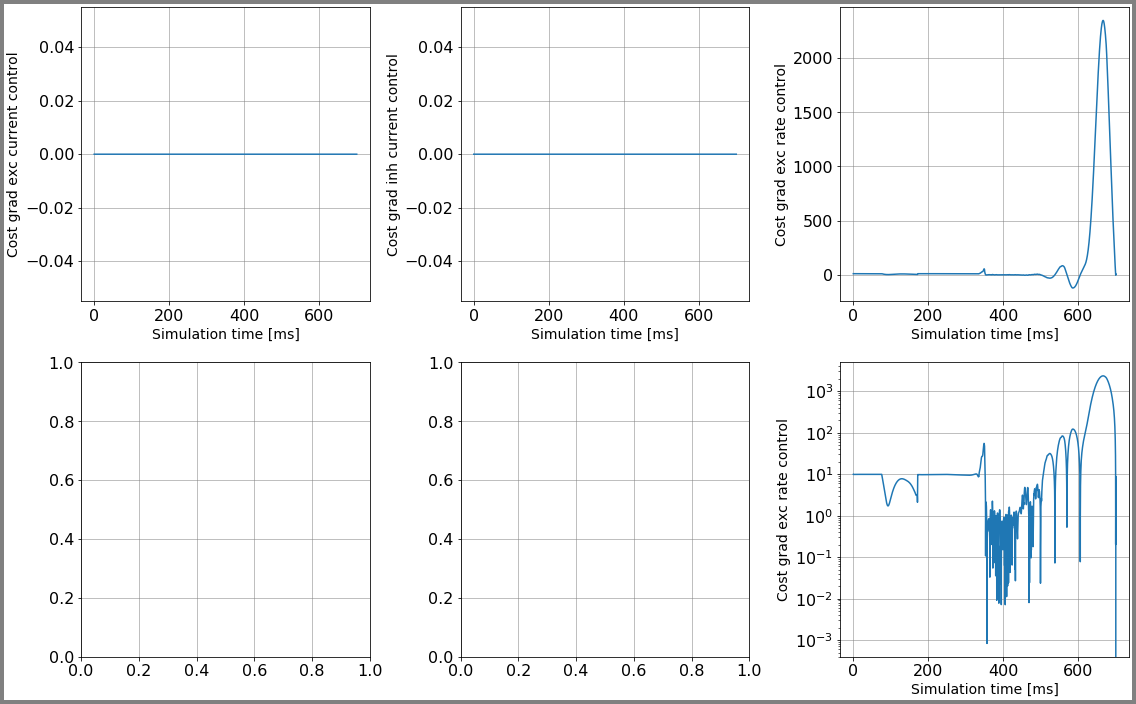

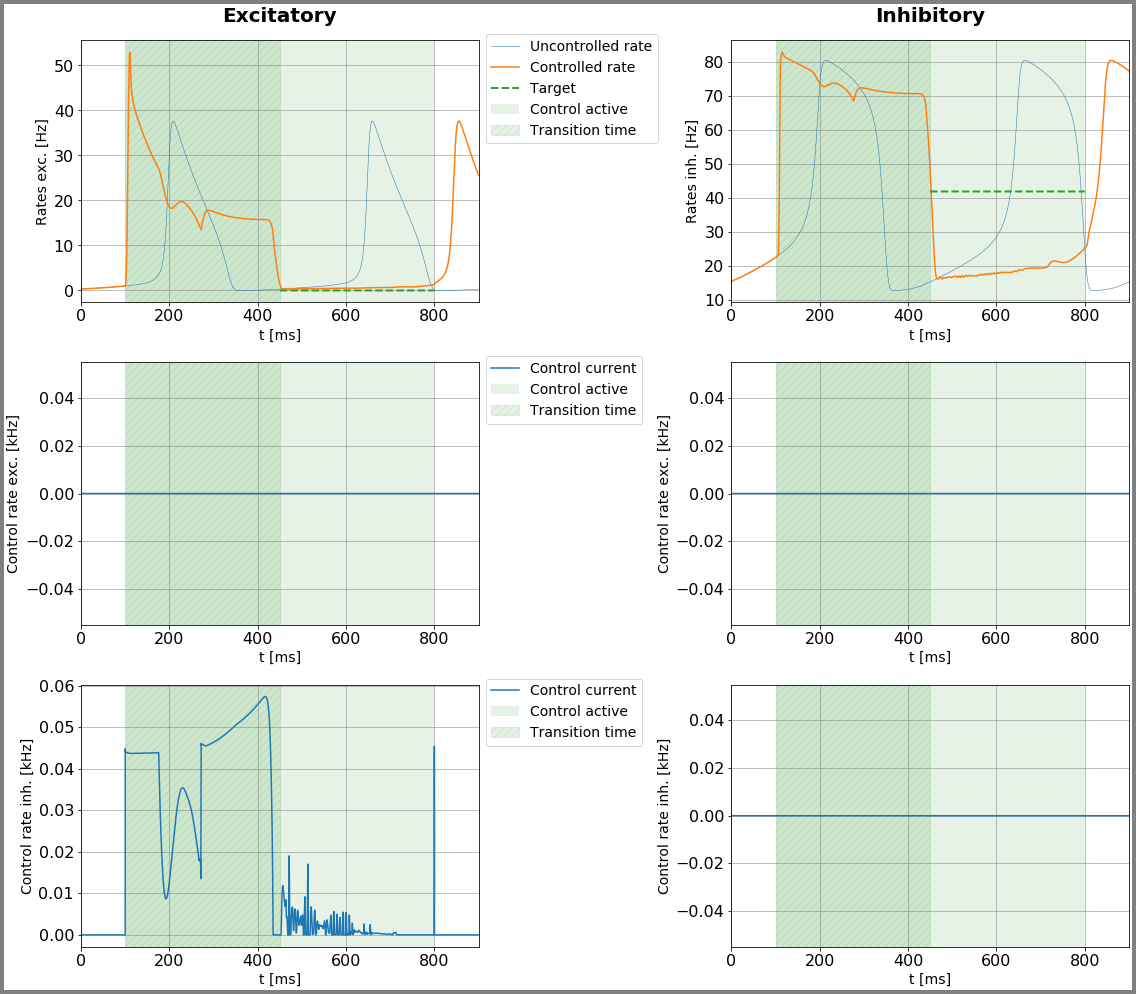

In [29]:
case_ind = 2
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 4

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42194.29441539813
RUN  1 , total integrated cost =  40993.388458386806
RUN  2 , total integrated cost =  32640.65217679402
RUN  3 , total integrated cost =  22395.921831819833
RUN  4 , total integrated cost =  19618.468838485856
RUN  5 , total integrated cost =  2184.7906031402
RUN  6 , total integrated cost =  511.50419669802403
RUN  7 , total integrated cost =  446.4717118367025
RUN  8 , total integrated cost =  98.29107138313809
RUN  9 , total integrated cost =  36.69081450966459
RUN  10 , total integrated cost =  20.949339322566377
RUN  11 , total integrated cost =  4.61944236996153
RUN  12 , total integrated cost =  0.7260462237137486
RUN  13 , total integrated cost =  0.19360094089883872
RUN  14 , total integrated cost =  0.03580649062136079
RUN  15 , total integrated cost =  0.017582905432921993
RUN  16 , total integrated cost =  0.003061376933702

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  2902 , total integrated cost =  2.8309407957613074e-07
Improved over  2902  iterations by  99.99999999932908  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -70.61005848188293 -70.6009291711971


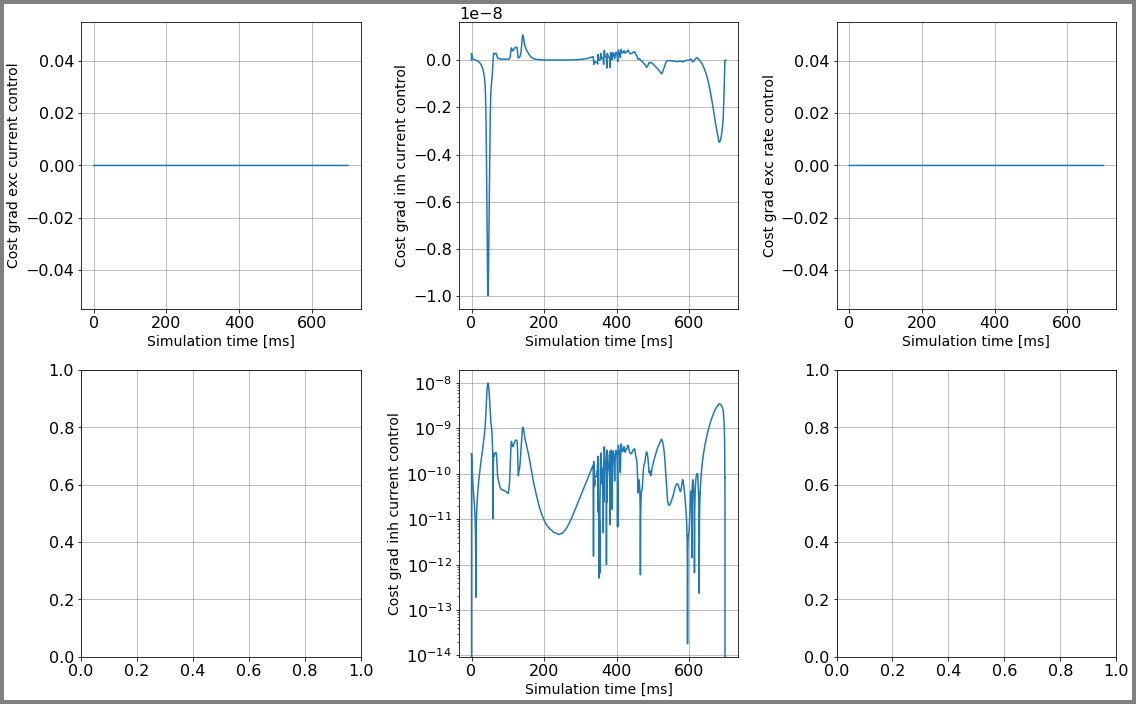

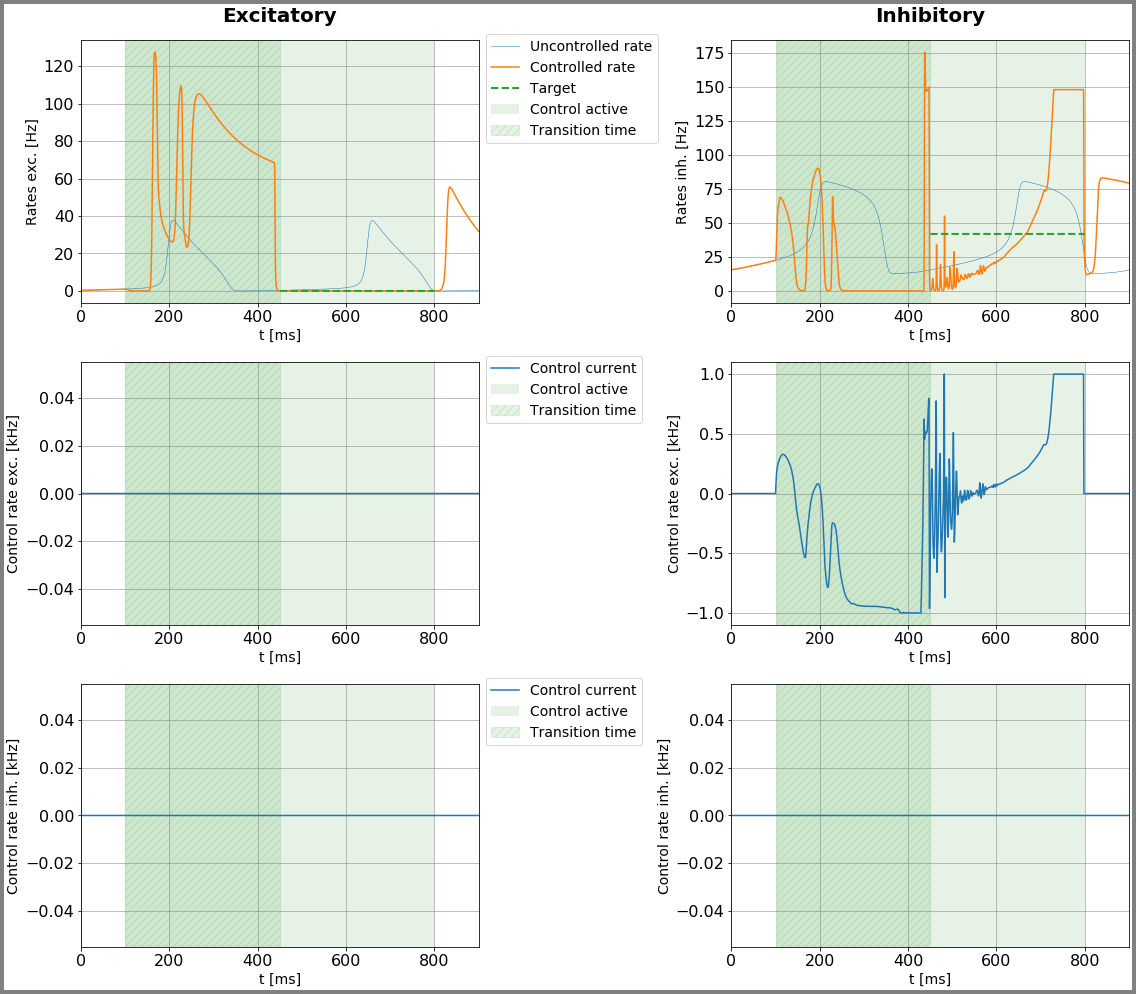

In [30]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.80261244179735
RUN  3 , total integrated cost =  48.296041359152305
RUN  4 , total integrated cost =  47.53091802892568
RUN  5 , total integrated cost =  46.723862799950766
RUN  6 , total integrated cost =  46.14622366154432
RUN  7 , total integrated cost =  45.522683595140656
RUN  8 , total integrated cost =  45.07507231216043
RUN  9 , total integrated cost =  44.55508395692323
RUN  10 , total integrated cost =  44.194362162084204
RUN  11 , total integrated cost =  43.8154262157795
RUN  12 , total integrated cost =  43.54733234694897
RUN  13 , total integrated cost =  43.28693411423703
RUN  14 , total integrated cost =  43.064468886565635
RUN  15 , total integrated cost =  42.834763981700604
RUN  16 , total integrated cost =  42.6407264337322
RUN  17 , total integrated cost =  42.45124089095

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  171 , total integrated cost =  39.90740205299795
Improved over  171  iterations by  37.47830856919616  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -60.64239500595997 -60.63689703456109


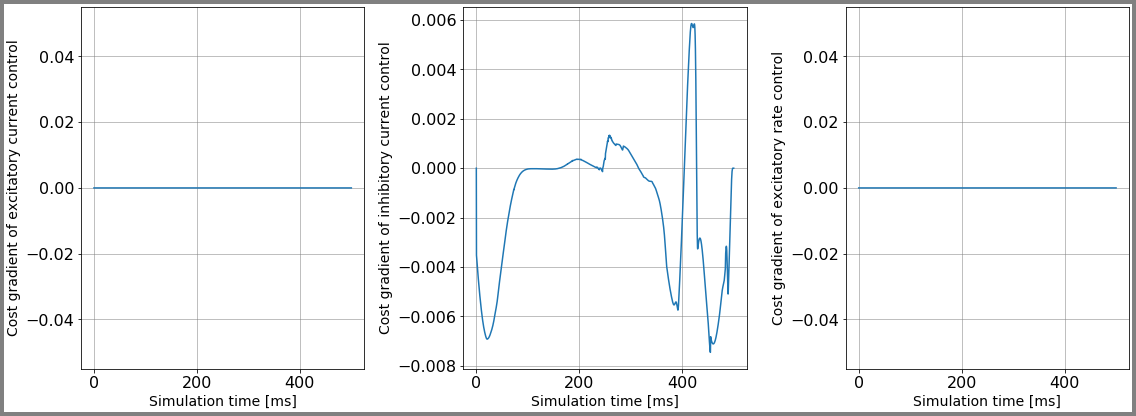

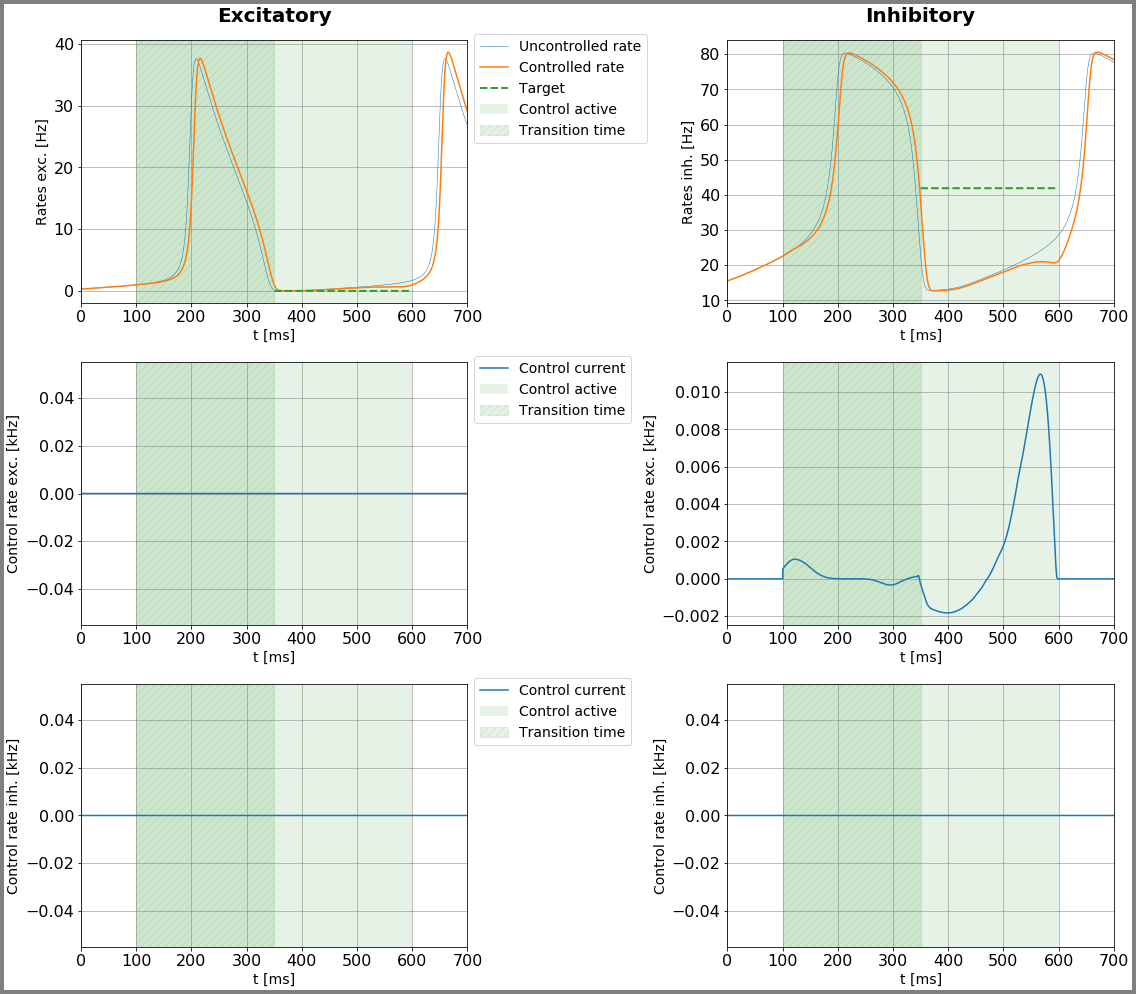

In [16]:
case_ind = 4
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42194.29441539813
RUN  1 , total integrated cost =  39072.23555042972
RUN  2 , total integrated cost =  360.9811518722101
RUN  3 , total integrated cost =  265.7947062033186
RUN  4 , total integrated cost =  158.69006856768107
RUN  5 , total integrated cost =  81.05768274489108
RUN  6 , total integrated cost =  36.84174263943
RUN  7 , total integrated cost =  8.019103124117148
RUN  8 , total integrated cost =  2.00130478889507
RUN  9 , total integrated cost =  0.3384580025389729
RUN  10 , total integrated cost =  0.04286974263326785
RUN  11 , total integrated cost =  0.00856585658198984
RUN  12 , total integrated cost =  0.001943188959673317
RUN  13 , total integrated cost =  0.0006032410390587193
RUN  14 , total integrated cost =  0.00015003521847141064
RUN  15 , total integrated cost =  3.7422050584180286e-05
RUN  16 , total integrated cost =  7.408

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  7.085395164637899e-23
RUN  5000 , total integrated cost =  7.085395164637899e-23
Improved over  5000  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -80.4265206702886 -80.31426877772671


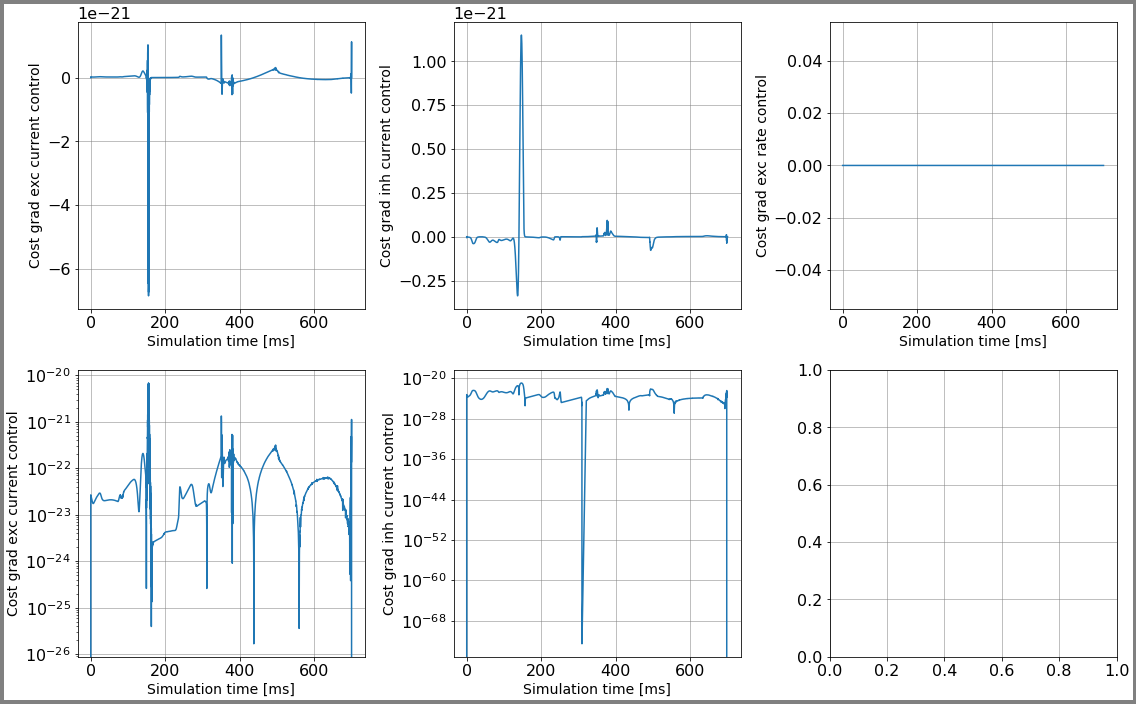

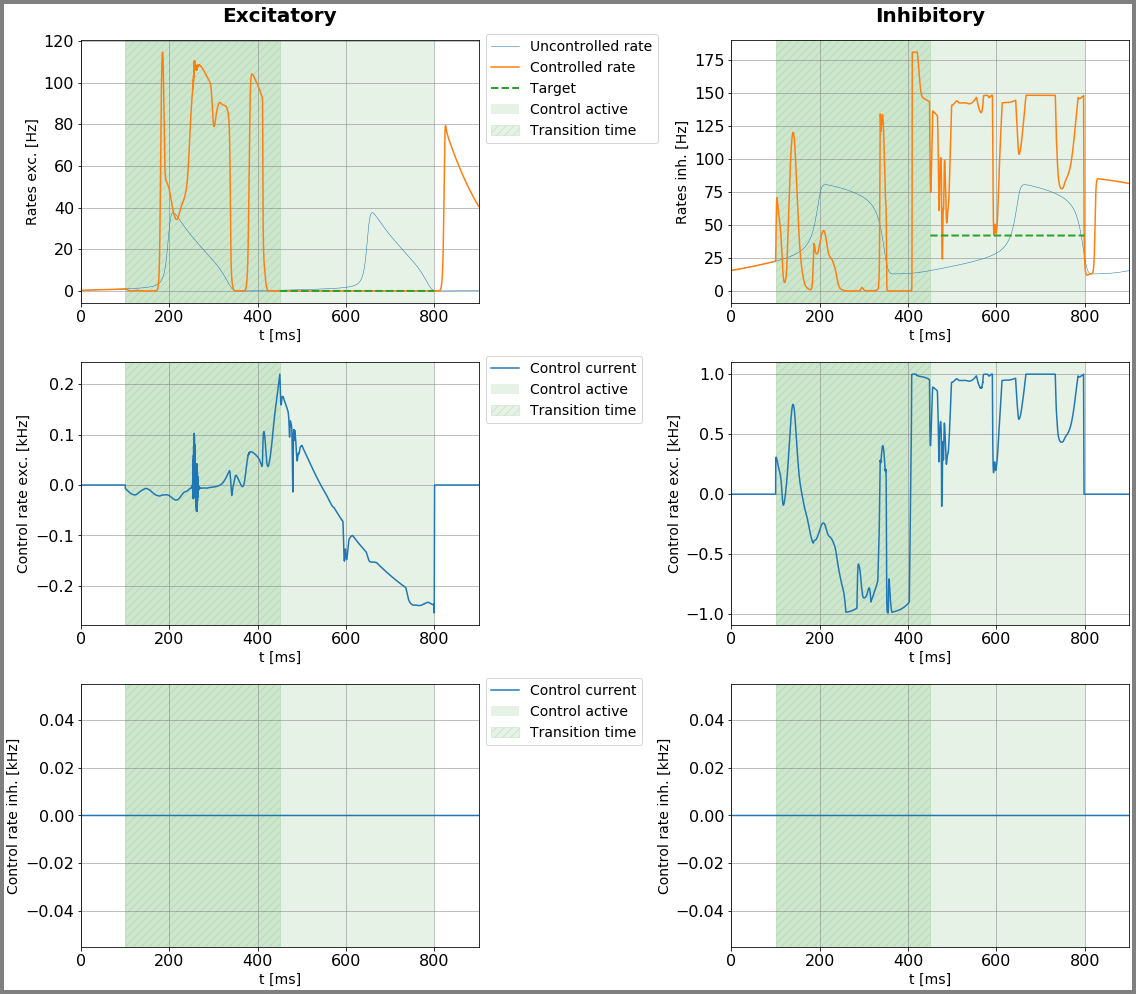

In [31]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.798045328038285
RUN  3 , total integrated cost =  48.2900523251189
RUN  4 , total integrated cost =  47.40133398079629
RUN  5 , total integrated cost =  46.43085991503662
RUN  6 , total integrated cost =  45.820908131101625
RUN  7 , total integrated cost =  45.14170761208009
RUN  8 , total integrated cost =  44.64709663388015
RUN  9 , total integrated cost =  44.105795395820074
RUN  10 , total integrated cost =  43.73747683675775
RUN  11 , total integrated cost =  43.339217761177345
RUN  12 , total integrated cost =  42.91109791198566
RUN  13 , total integrated cost =  42.42498965203981
RUN  14 , total integrated cost =  41.889061914847424
RUN  15 , total integrated cost =  41.35179323766258
RUN  16 , total integrated cost =  41.17926649778656
RUN  17 , total integrated cost =  41.00040829130

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  126 , total integrated cost =  37.54822369247924
Improved over  126  iterations by  41.17436027636311  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -60.77919081635182 -60.77282447289306


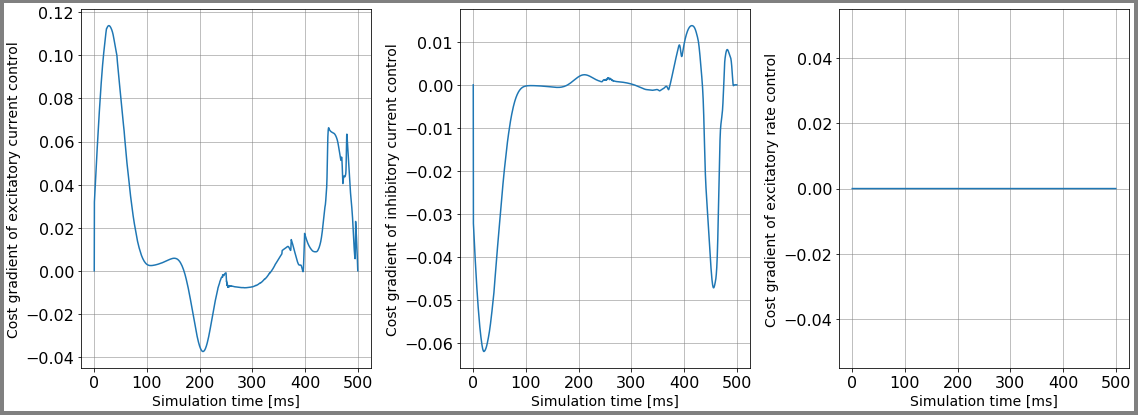

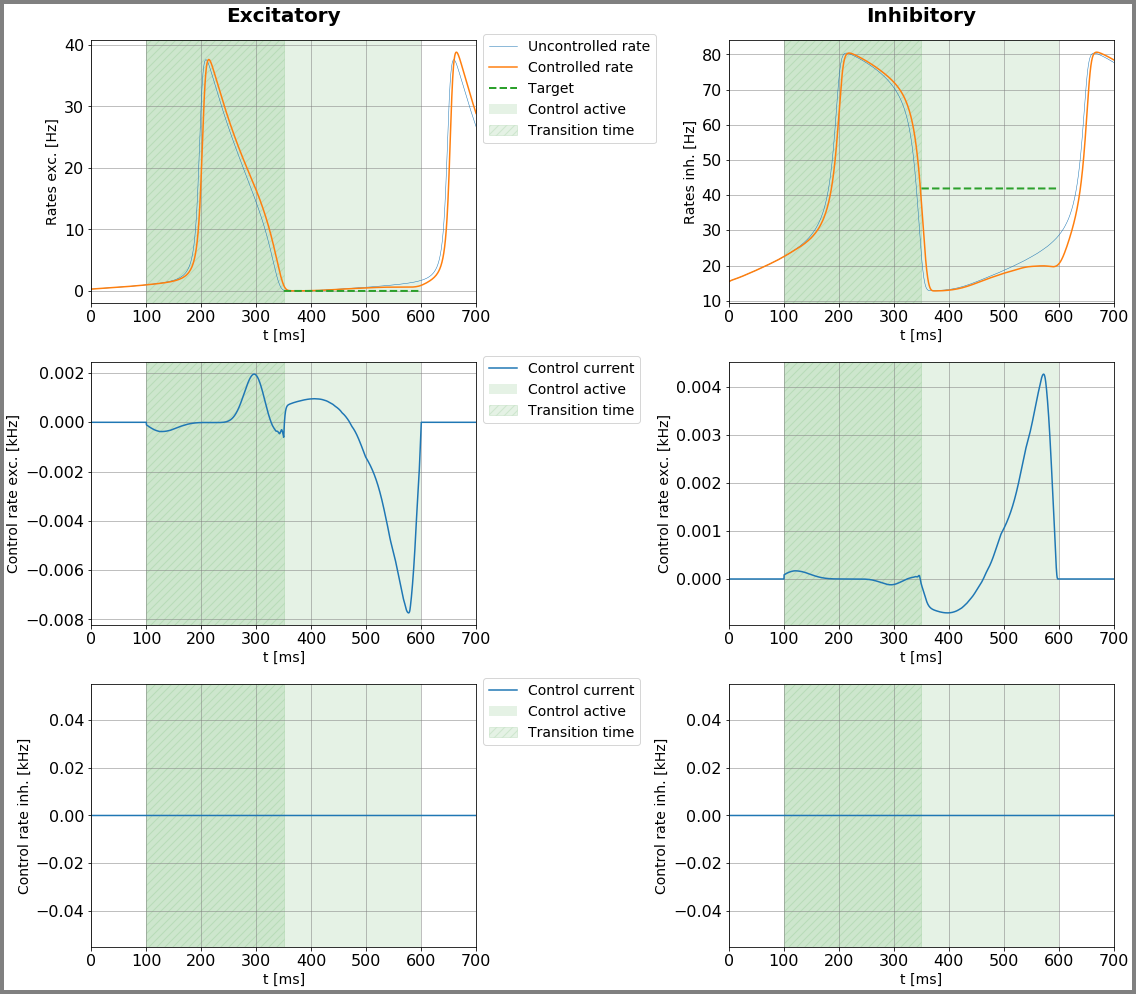

In [18]:
case_ind = 6
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  2.4390770427590896e-17
RUN  2 , total integrated cost =  2.4390770422651262e-17
RUN  3 , total integrated cost =  2.4390770422166695e-17
RUN  4 , total integrated cost =  2.439077042216504e-17
RUN  5 , total integrated cost =  2.4390770422143956e-17
RUN  6 , total integrated cost =  2.4390770422132703e-17
RUN  7 , total integrated cost =  2.4390770422132086e-17
RUN  8 , total integrated cost =  2.4390770422132083e-17


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  2.4390770422132083e-17
Control only changes marginally.
RUN  9 , total integrated cost =  2.4390770422132083e-17
Improved over  9  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5295732535605777
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.558370132448914
Problem in initial value trasfer:  tau_exc 14.884010616351775 15.367530762918687


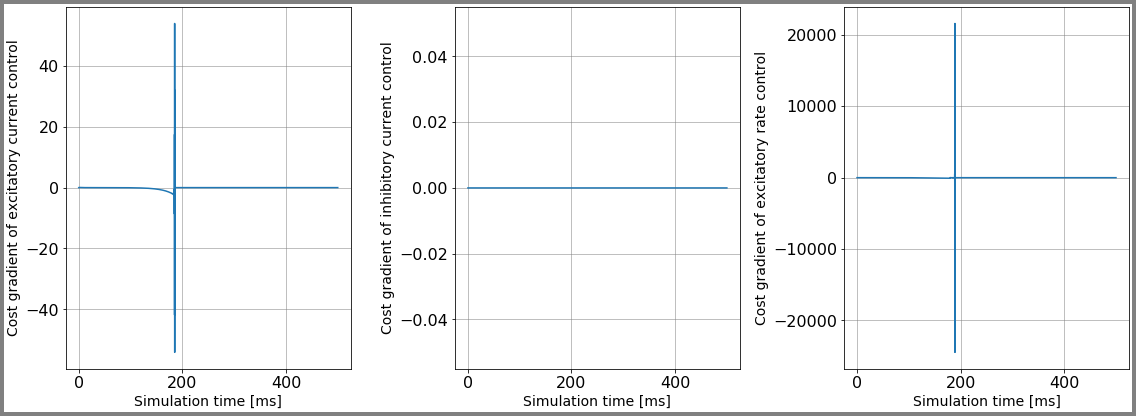

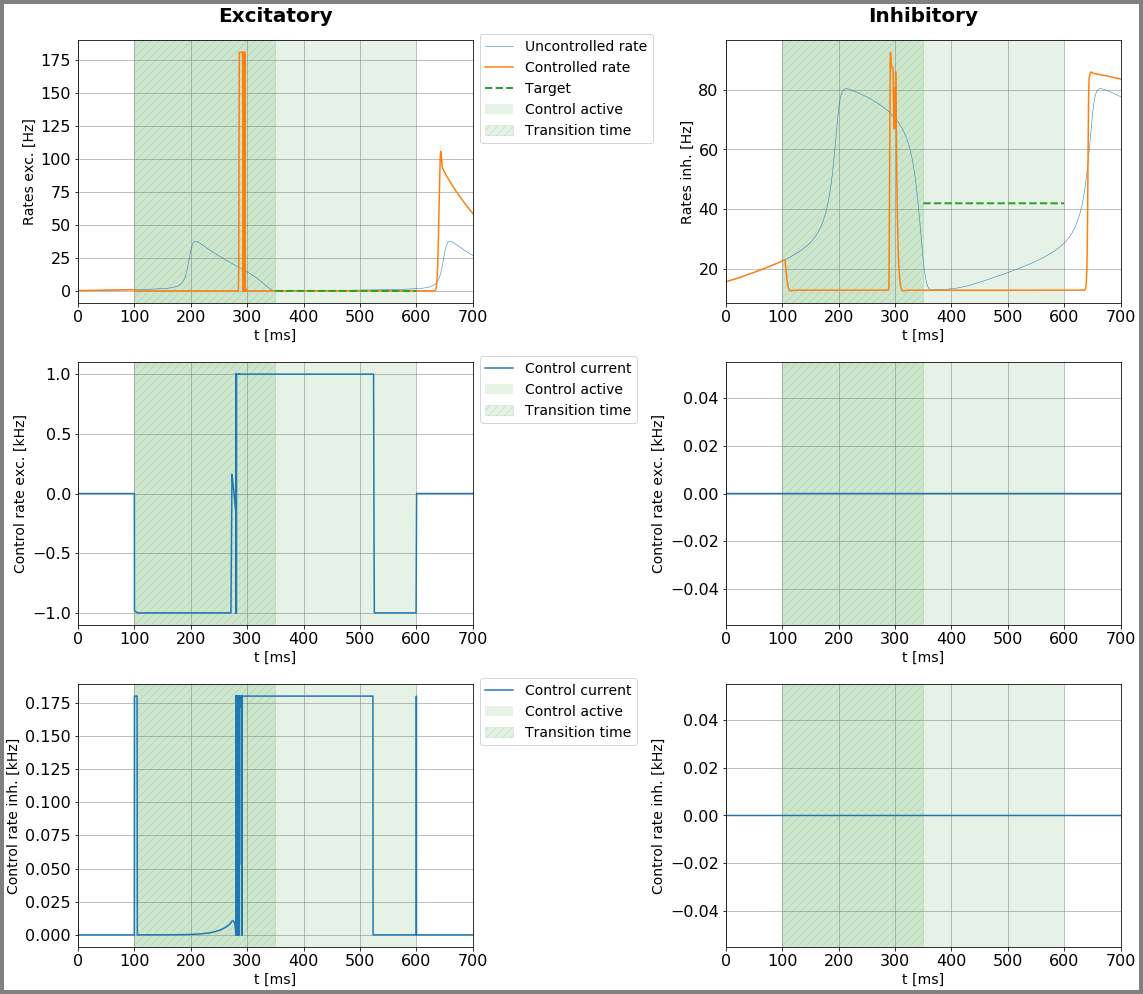

In [19]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.793336333878
RUN  2 , total integrated cost =  50.45638423201447
RUN  3 , total integrated cost =  46.96884496652877
RUN  4 , total integrated cost =  41.25619523997098
RUN  5 , total integrated cost =  38.754412477165204
RUN  6 , total integrated cost =  36.50692959069962
RUN  7 , total integrated cost =  36.278823337237476
RUN  8 , total integrated cost =  35.444417045318616
RUN  9 , total integrated cost =  34.54359310874364
RUN  10 , total integrated cost =  34.36788174355688
RUN  11 , total integrated cost =  33.94892164349723
RUN  12 , total integrated cost =  33.59710718171118
RUN  13 , total integrated cost =  33.54207513453429
RUN  14 , total integrated cost =  33.29081416792376
RUN  15 , total integrated cost =  33.17502667412432
RUN  16 , total integrated cost =  33.10983434398376
RUN  17 , total integrated cost =  32.964277104365664

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  79 , total integrated cost =  30.923613786815466
Improved over  79  iterations by  51.55293154545534  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5667320471019917
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095429813288
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.884047254195902
Problem in initial value trasfer:  Vmean_exc -60.83703437754855 -60.83521851254697


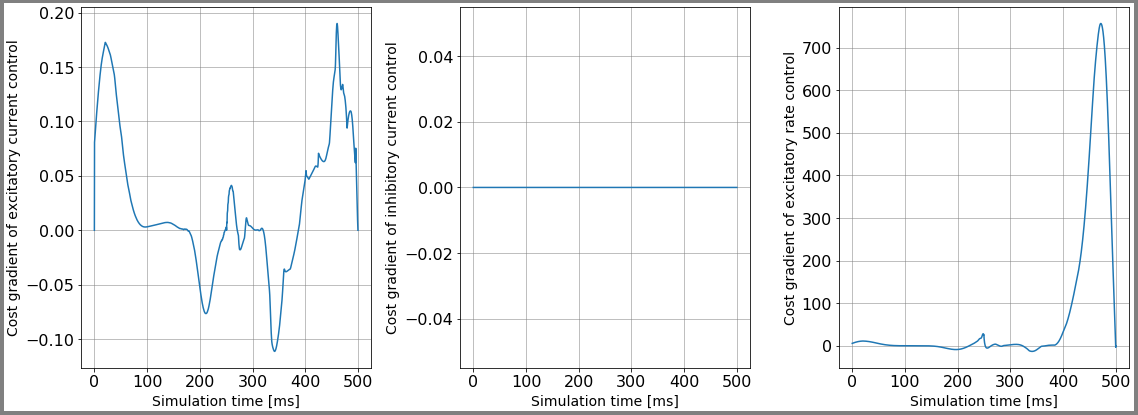

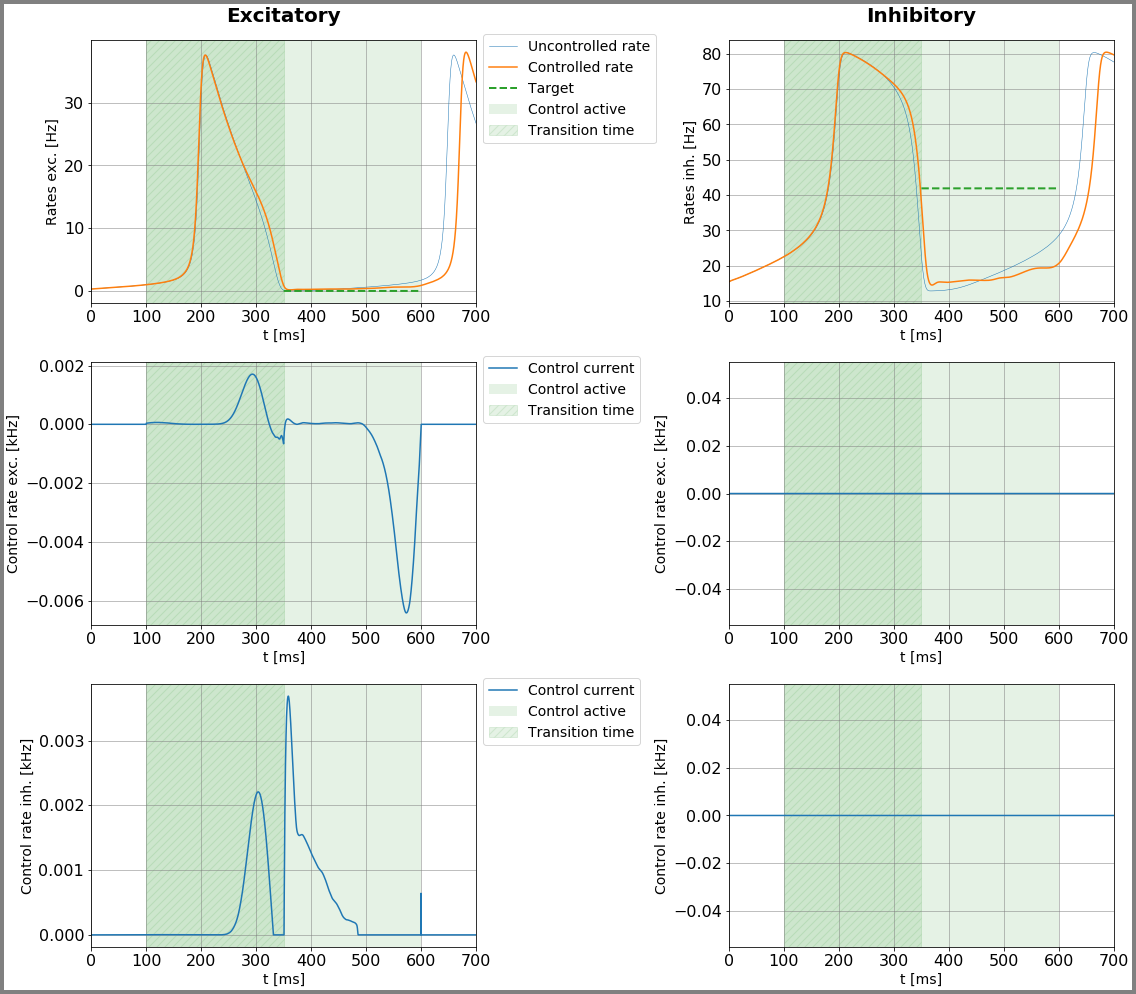

In [20]:
case_ind = 8
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.944162410139565e-06
RUN  1 , total integrated cost =  4.754313172311215e-06
RUN  2 , total integrated cost =  4.541850398591434e-06
RUN  3 , total integrated cost =  4.300987049314496e-06
RUN  4 , total integrated cost =  4.155200784823657e-06
RUN  5 , total integrated cost =  4.0068461500820345e-06
RUN  6 , total integrated cost =  3.876600757327994e-06
 max iteration reached, step size =  7.820637090558988e-148
 max iteration reached, step size =  1.0010415475915505e-145
RUN  7 , total integrated cost =  3.753275716018658e-06
RUN  8 , total integrated cost =  3.5444779659218447e-06
 max iteration reached, step size =  7.820637090558988e-148
 max iteration reached, step size =  1.2813331809171846e-143
RUN  9 , total integrated cost =  3.449472332206873e-06
RUN  10 , total integrated cost =  3.284769202260012e-06
 max iteration reached, step size = 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  1.7068542377567107e-06
RUN  40 , total integrated cost =  1.7068542377567107e-06
Improved over  40  iterations by  65.47738330245245  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5295727170742817
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.55836937325112
Problem in initial value trasfer:  tau_exc 14.884010616351775 15.367537743292699
Problem in initial value trasfer:  Vmean_exc -69.82064000987968 -69.80228082171313


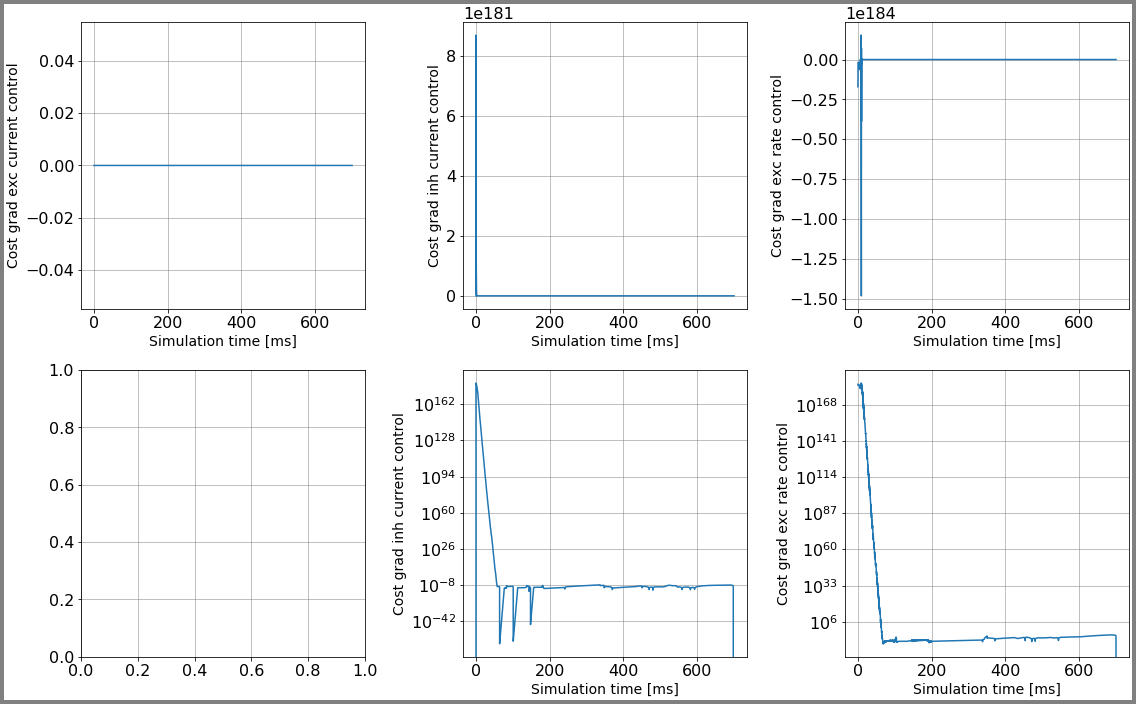

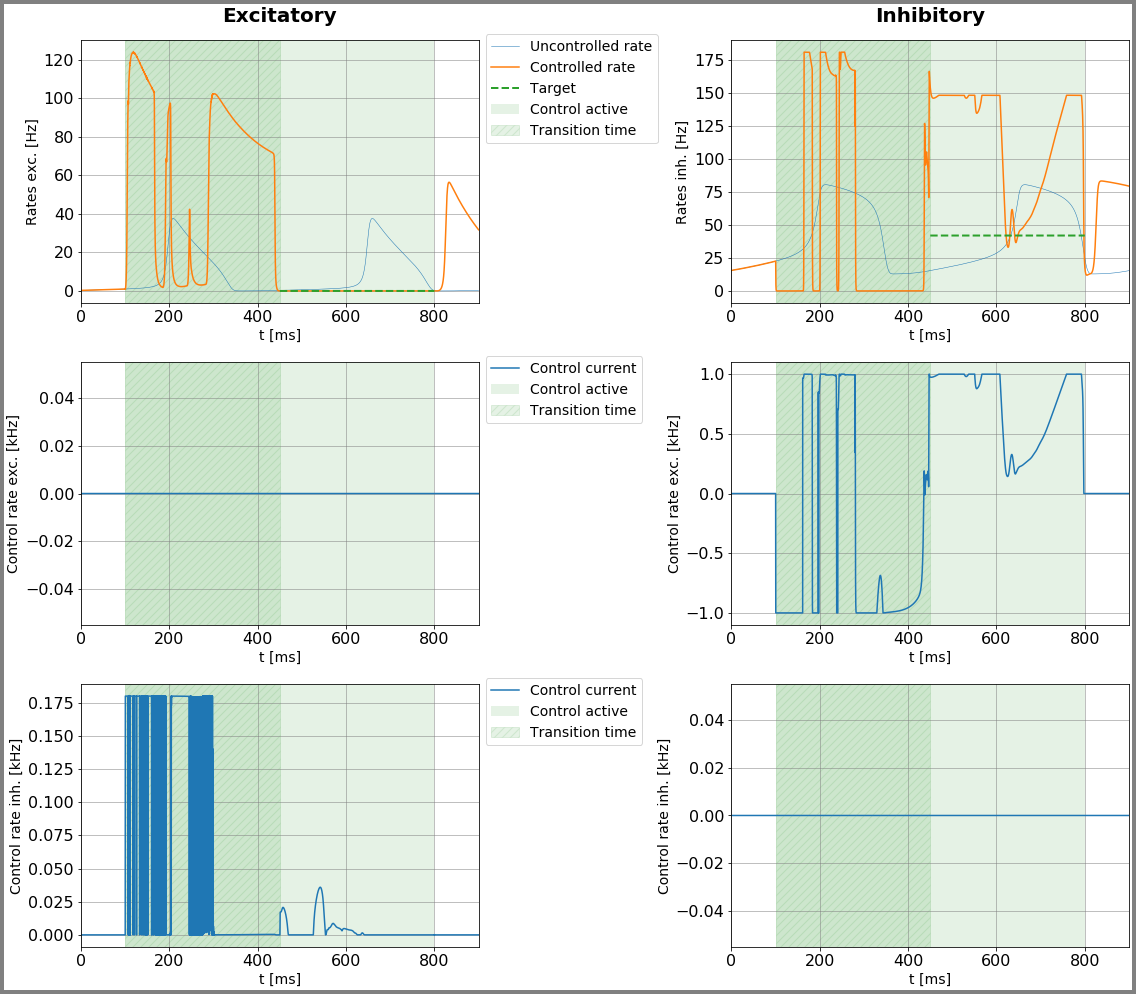

In [32]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 40

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.80261244179735
RUN  3 , total integrated cost =  46.31165522125741
RUN  4 , total integrated cost =  40.63473655533605
RUN  5 , total integrated cost =  38.356936233779564
RUN  6 , total integrated cost =  36.768781658711646
RUN  7 , total integrated cost =  36.06901165268232
RUN  8 , total integrated cost =  35.375478176279046
RUN  9 , total integrated cost =  35.15942768198916
RUN  10 , total integrated cost =  34.72055238737128
RUN  11 , total integrated cost =  34.40228644214362
RUN  12 , total integrated cost =  33.92027875073553
RUN  13 , total integrated cost =  33.67996460717333
RUN  14 , total integrated cost =  33.44562276252591
RUN  15 , total integrated cost =  33.30571489687487
RUN  16 , total integrated cost =  33.110803914492664
RUN  17 , total integrated cost =  32.88134334837

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  554 , total integrated cost =  31.245901345650275
Improved over  554  iterations by  51.048013603698635  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.566720453664532
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.610937892020914
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.8841980996698
Problem in initial value trasfer:  Vmean_exc -60.78590415938706 -60.78728946310402


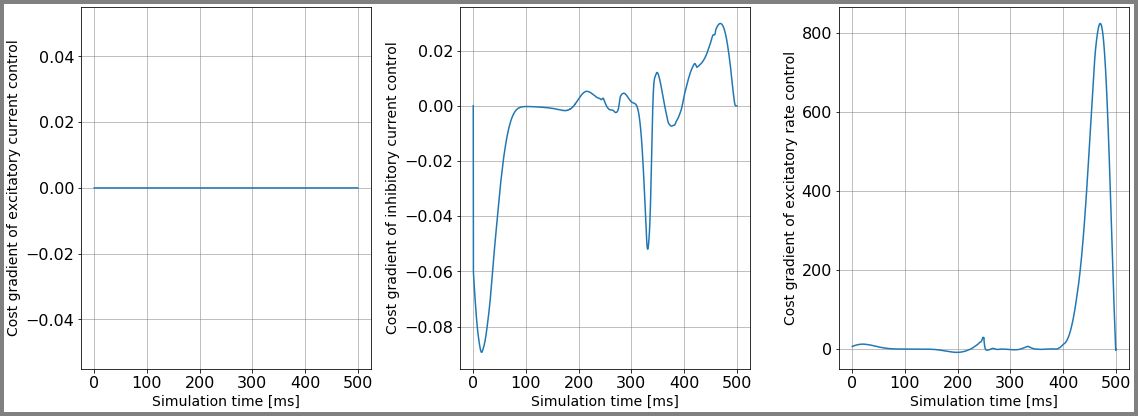

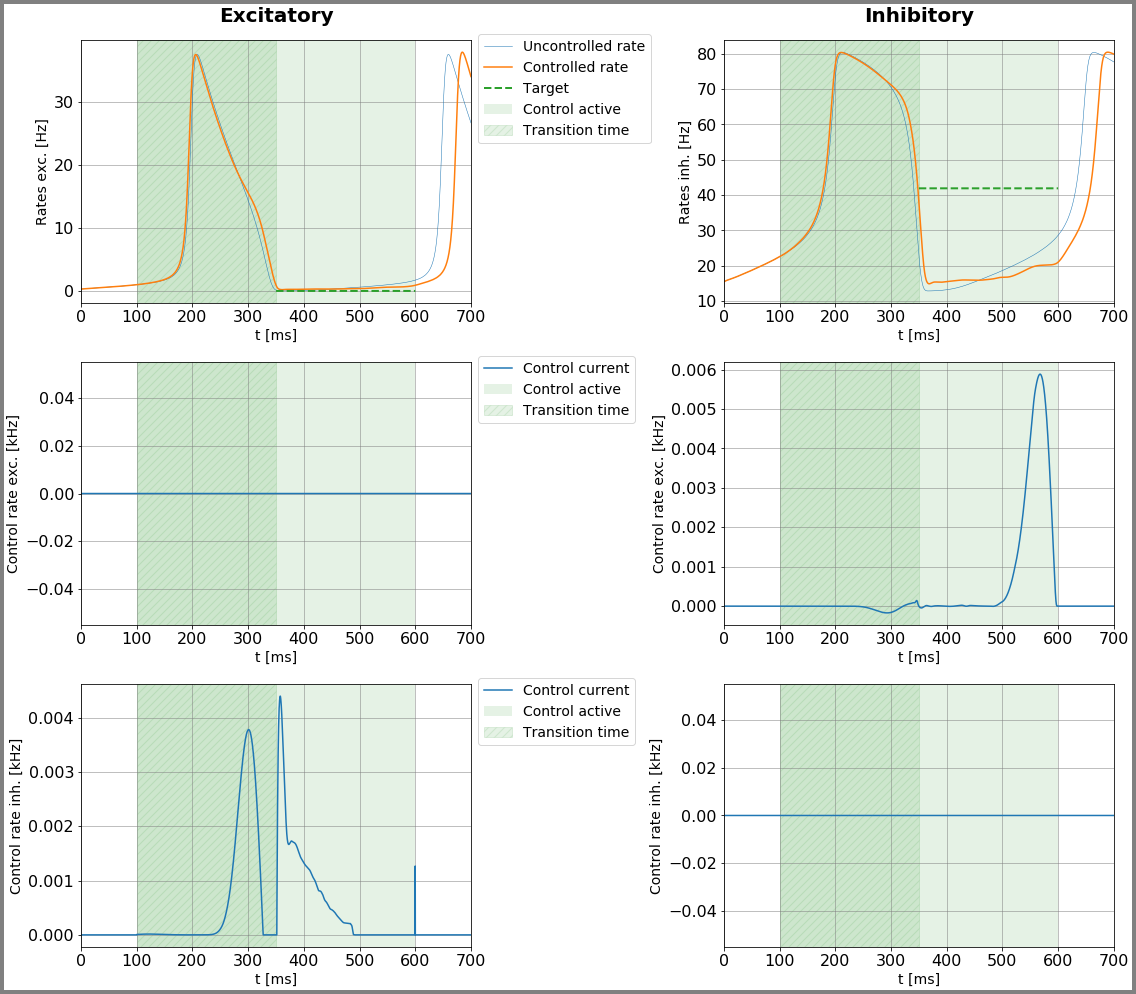

In [22]:
case_ind = 10
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  2.4802282952983123e-17
RUN  2 , total integrated cost =  2.480228258118777e-17
RUN  3 , total integrated cost =  2.4802282560264027e-17
RUN  4 , total integrated cost =  2.4802242304403905e-17
RUN  5 , total integrated cost =  2.4801083677158953e-17
RUN  6 , total integrated cost =  2.4792360718174653e-17
RUN  7 , total integrated cost =  2.4792341050315413e-17
RUN  8 , total integrated cost =  2.4792341049874742e-17
RUN  9 , total integrated cost =  2.4765910996540547e-17


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  2.4765910996540547e-17
Control only changes marginally.
RUN  10 , total integrated cost =  2.4765910996540547e-17
Improved over  10  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5295727170742817
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.55836937325112
Problem in initial value trasfer:  tau_exc 14.884010616351775 15.367537743292699


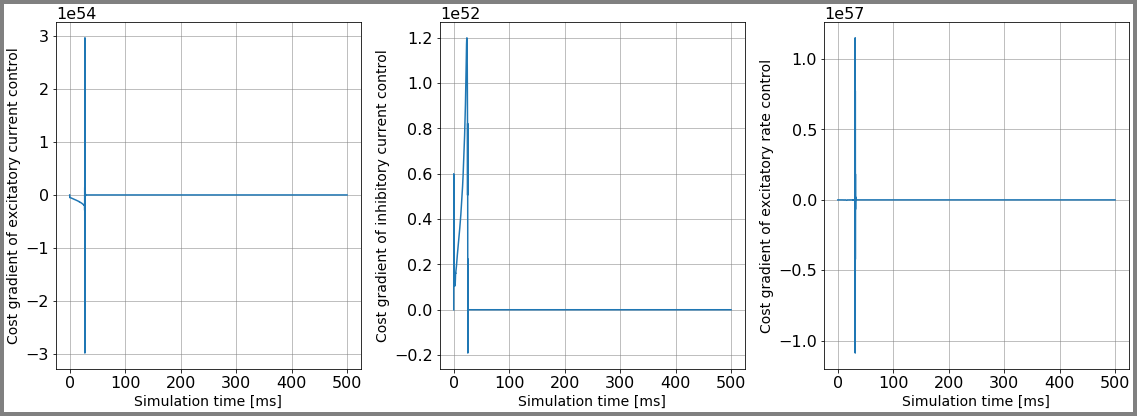

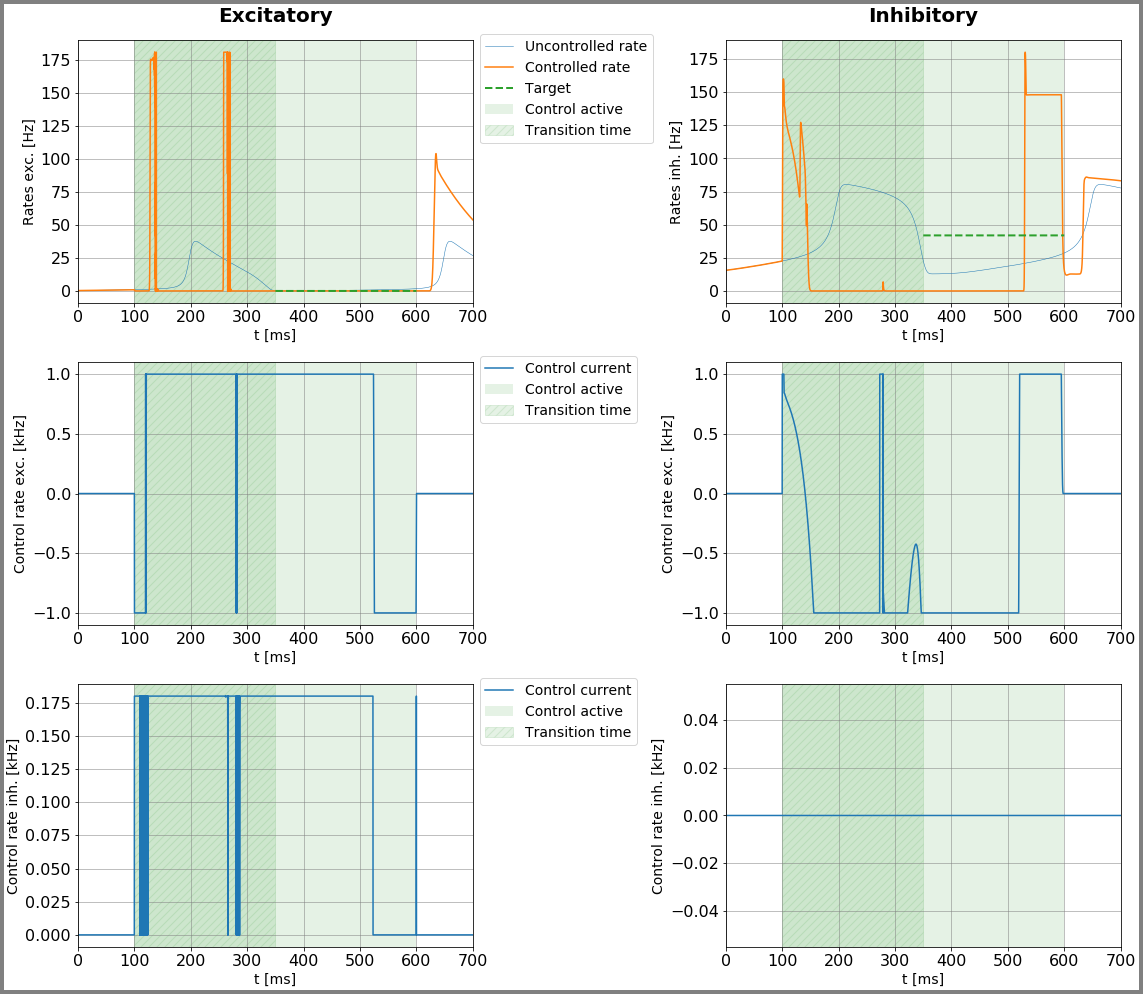

In [23]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.80261244179735
RUN  3 , total integrated cost =  46.291915091941654
RUN  4 , total integrated cost =  40.599592880098626
RUN  5 , total integrated cost =  38.33753478588997
RUN  6 , total integrated cost =  36.216310254454484
RUN  7 , total integrated cost =  33.8929740833154
RUN  8 , total integrated cost =  33.07603096642063
RUN  9 , total integrated cost =  32.7132391769871
RUN  10 , total integrated cost =  32.25348314866228
RUN  11 , total integrated cost =  32.18438542307515
RUN  12 , total integrated cost =  31.967892580850616
RUN  13 , total integrated cost =  31.878534216272666
RUN  14 , total integrated cost =  31.81631757153808
RUN  15 , total integrated cost =  31.687150861050092
RUN  16 , total integrated cost =  31.634088416558168
RUN  17 , total integrated cost =  31.5164958339

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  127 , total integrated cost =  30.65535962006616
Improved over  127  iterations by  51.97319704447866  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.566730868793417
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.610952630679286
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.88406258550001
Problem in initial value trasfer:  Vmean_exc -60.8661896640328 -60.865407816574944


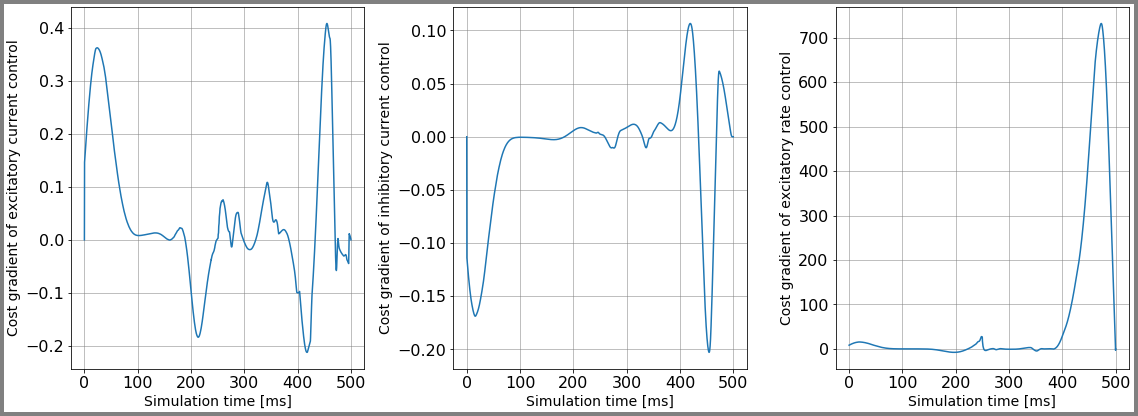

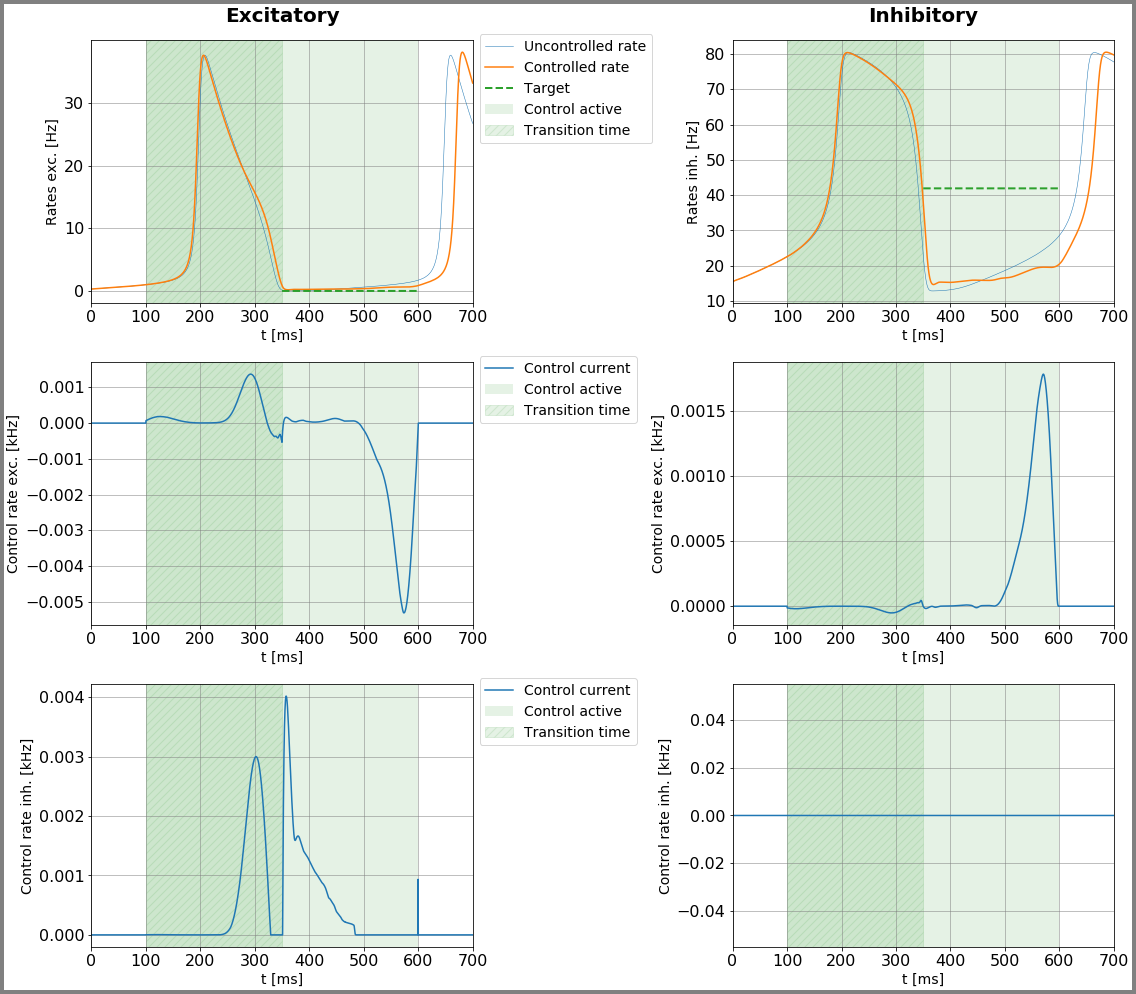

In [24]:
case_ind = 12
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )